In [15]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [16]:
#Extraction du dataset Kaggle

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [17]:
#Charger les données
data = pd.read_csv(path + '/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##Exploration des données

In [18]:
#3Information sur la data
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#Vérification des valeurs manquantes
print(data.isnull().sum())
print(data.isna().sum())
#Vérification des doublons
print(data.duplicated().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0


In [ ]:
#Statistiques descriptives
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


###Distribution de la variable cible Churn

Churn
No     5174
Yes    1869
Name: count, dtype: int64


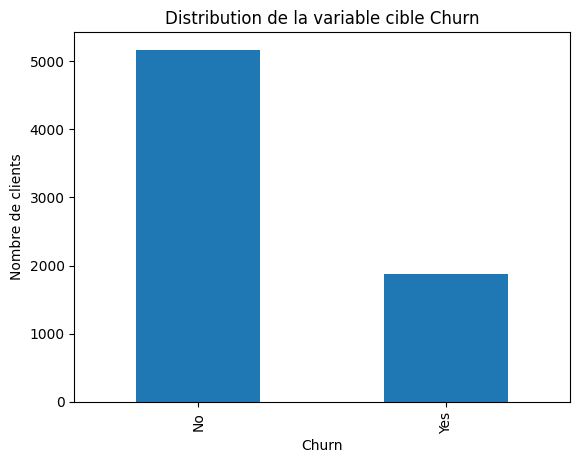

In [ ]:
#Classes de la variable cible
print(data['Churn'].value_counts())

#Distribution de la variable cible
data['Churn'].value_counts().plot(kind='bar')
plt.title('Distribution de la variable cible Churn')
plt.xlabel('Churn')
plt.ylabel('Nombre de clients')
plt.show()


In [ ]:
cat_cols = data.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\nDistribution de {col}")
    print(data[col].value_counts())


Distribution de customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

Distribution de gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Distribution de Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Distribution de Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Distribution de PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Distribution de MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Distribution de InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Distribution de OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No intern

NaN après suppression : 0


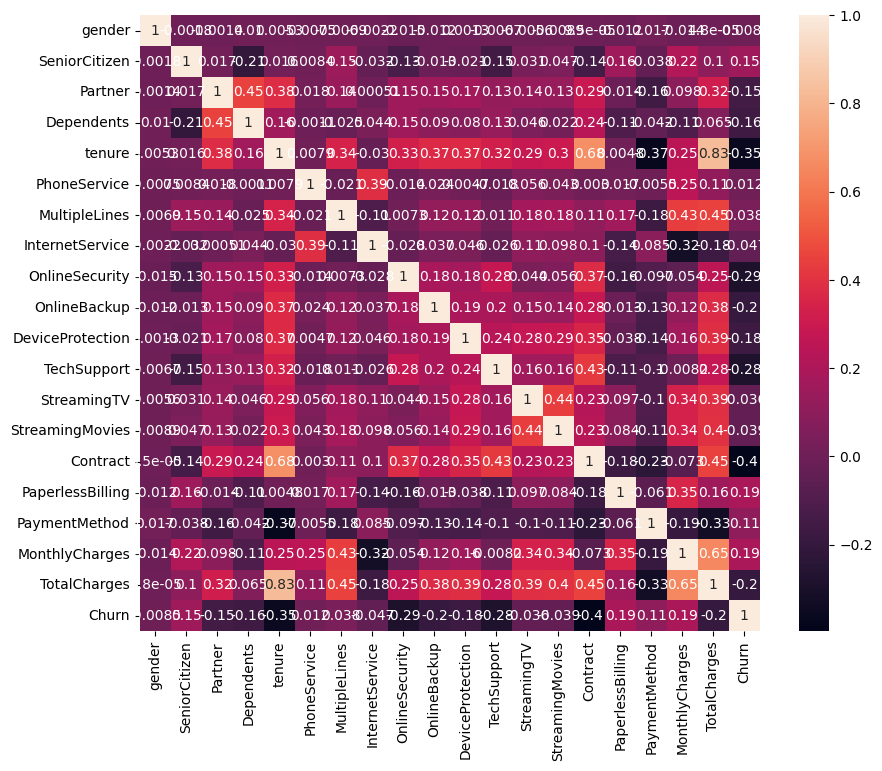

In [19]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

data = data.dropna()

print("NaN après suppression :", data.isna().sum().sum())

# Convertir les colonnes catégorielles en numériques
cat_cols = data.select_dtypes(include="object").columns
for col in cat_cols:
    data[col] = data[col].astype("category").cat.codes

# Supprimer la colonne customerID si elle existe
if "customerID" in data.columns:
    data = data.drop("customerID", axis=1)

# Afficher la matrice de corrélation
corr_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True)
plt.show()

#Analyse de la matrice de corrélation

La matrice de corrélation permet d’identifier les relations entre les variables explicatives et la variable cible Churn. Les coefficients varient entre -1 et 1, indiquant respectivement une corrélation négative forte ou positive forte.

On observe que certaines variables sont plus corrélées avec le churn, notamment Contract (-0.40), tenure (-0.35), OnlineSecurity (-0.29) et TechSupport (-0.28). Ces résultats suggèrent que les clients ayant un contrat plus long, une ancienneté élevée ou bénéficiant de services de support ont tendance à moins quitter le service.

À l’inverse, certaines variables comme gender ou PhoneService présentent une corrélation très faible avec le churn, indiquant un impact limité sur la prédiction.

Par ailleurs, une forte corrélation est observée entre tenure et TotalCharges (0.83), ce qui traduit une redondance d’information puisque le montant total payé dépend directement de la durée d’abonnement. Cette redondance doit être prise en compte lors de la sélection des variables.

#Variables faiblement corrélées avec le churn

Certaines variables présentent une corrélation très faible avec Churn, suggérant qu’elles ont probablement un impact limité sur la prédiction :

-gender

-PhoneService

-StreamingTV

-StreamingMovies

-MultipleLines

##Supression des features peu impactantes

In [23]:
features_to_drop = [
    "gender",
    "PhoneService",
    "StreamingTV",
    "StreamingMovies",
    "TotalCharges"
]

# Drop columns only if they exist in the DataFrame
data = data.drop(columns=[col for col in features_to_drop if col in data.columns])

# Sauvegarder dataset en csv
data.to_csv('dataset.csv', index=False)

In [24]:
data.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,1,0,1,1,0,0,2,0,0,0,1,2,29.85,0
1,0,0,0,34,0,0,2,0,2,0,1,0,3,56.95,0
2,0,0,0,2,0,0,2,2,0,0,0,1,3,53.85,1
3,0,0,0,45,1,0,2,0,2,2,1,0,0,42.30,0
4,0,0,0,2,0,1,0,0,0,0,0,1,2,70.70,1
